Steps:
- Pip install clinica: aramis-lab/clinica: Software platform for clinical neuroimaging studies
- Convert publicly available ADNI neuroimaging dataset into BIDS - Brain Imaging Data Structure = specification - simple and easy way to organize/structure neuroimaging data  
  - unzip ADNI dataset 
    - Enabled long path support using regedit - HKEY_LOCAL_MACHINE\SYSTEM\CurrentControlSet\Control\FileSystem\LongPathsEnabled=1
  - convert using Clinca's ADNI converter - T1-weighting MRI preprocessing 
  - python -m pip install dcm2niix
    - sudo apt-get install cmake and sudo make install for dcm2niix: https://github.com/rordenlab/dcm2niix
- mpragemeta.CSV NOT THERE ANYMORE: https://groups.google.com/g/clinica-user/c/3QO4ZK9uN_g

In [1]:
import ants
import antspynet
import os
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.ndimage
from tqdm import tqdm

2025-05-07 12:07:12.702898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-07 12:07:12.826823: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746637632.902053 2896688 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746637632.921079 2896688 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746637633.030584 2896688 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

 filter to about 358 patients, between the ages of 70 and 84 (mean 77 +/ 7), AD and CN patients only, T1 weighted, original images (will do own custom processing)

In [2]:
# Read clinical data to merge diagnosis with patient's image using RID (Participant ID)

# 

CLINICAL_PATH = "./clinical/ADNIMERGE_04May2025.csv"

clinical_df = pd.read_csv(CLINICAL_PATH)

# binary classification - alzheimer's disease or not 
# Diagnosis = DX DX_bl = diagnosis at baseline CN = cognitively normal, AD = Alzheimer's Disease 

# Remove records without a diagnosis nor image uid
clinical_df = clinical_df[~clinical_df['DX'].isna()]
clinical_df = clinical_df[~clinical_df['IMAGEUID'].isna()]
# Remove dementia or non healthy controls of matched age to AD patients
print("Average age of AD patients: ", clinical_df['AGE'].mean())
print("Number of unique patients: ", clinical_df['RID'].nunique())
clinical_df[['RID', 'DX', 'MMSE', 'IMAGEUID', 'Hippocampus', 'Ventricles', 'EXAMDATE']] # Diagnosis at baseline

Average age of AD patients:  73.2193666129898
Number of unique patients:  2350


/tmp/ipykernel_2896688/686826295.py:7: DtypeWarning:

Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.



,RID,DX,MMSE,IMAGEUID,Hippocampus,Ventricles,EXAMDATE
0,2,CN,28.0,35475.0,8336.0,118233.0,2005-09-08
1,3,Dementia,20.0,32237.0,5319.0,84599.0,2005-09-12
2,3,Dementia,24.0,31863.0,5446.0,88580.0,2006-03-13
3,3,Dementia,17.0,35576.0,5157.0,90099.0,2006-09-12
4,3,Dementia,19.0,88252.0,5139.0,97420.0,2007-09-12
...,...,...,...,...,...,...,...
16218,6473,CN,30.0,1637836.0,6465.5,32282.1,2022-11-01
16227,6830,MCI,22.0,1642034.0,6103.2,71941.0,2022-11-15
16235,7114,CN,30.0,1633742.0,7717.3,15983.4,2022-11-16
16238,2155,Dementia,19.0,1644018.0,5097.0,38172.6,2022-11-21


In [3]:
import ants
import antspynet
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
t1_path_test = '/home/ggibson/CS598Project3/ADNI/002_S_0413/MPR____N3__Scaled/2006-05-19_16_17_47.0/I40657/ADNI_002_S_0413_MR_MPR____N3__Scaled_Br_20070216232854688_S14782_I40657.nii'

# Step 1: Load image directly with ANTs
t1 = ants.image_read(t1_path_test)

# Step 2: Confirm type and shape
print("ANTs image loaded:", type(t1))
print("Shape:", t1.shape)
print("Spacing:", t1.spacing)

# Step 3: Bias field correction (optional)
t1_corrected = ants.n4_bias_field_correction(t1)

# Step 4: Convert to array (to see if this causes the error early)
try:
    test_array = t1_corrected.numpy()
    print("Array conversion successful, shape:", test_array.shape)
except Exception as e:
    print("Failed to convert ANTs image to NumPy array:", e)

# Step 5: Try brain extraction
try:
    brain = antspynet.brain_extraction(t1_corrected, modality="t1", verbose=True)
    brain.to_filename("brain_extracted.nii.gz")
    print("Brain extraction successful. Saved output.")
except Exception as e:
    print("Brain extraction failed:", e)

# Step 5.1: strip the skull from the t1_corrected image
t1_skull_stripped = t1_corrected * brain

# Step 6: Register to MNI Space
template = ants.image_read(ants.get_ants_data("mni"))
reg = ants.registration(fixed=template, moving=t1_skull_stripped, type_of_transform="Affine")
print("Registered to MNI Space\n")

ANTs image loaded: <class 'ants.core.ants_image.ANTsImage'>
Shape: (256, 256, 170)
Spacing: (0.9996359944343567, 1.0046390295028687, 1.2031749486923218)
Array conversion successful, shape: (256, 256, 170)
Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Brain extraction:  renormalize probability mask to native space.
Brain extraction successful. Saved output.


In [12]:
import torch
print(torch.cuda.memory_summary())
torch.cuda.empty_cache()
import torch
print(torch.version.cuda)
print(torch.__version__)

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [10]:
# force cpu processing
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# still didn't help the memory issues 

In [13]:
# perform preprocessing on the entire image dataset
def preprocess_image(t1_path, processed_dir_path):
    t1 = ants.image_read(t1_path)

    # Step 2: Confirm type and shape
    print("ANTs image loaded:", type(t1))
    print("Shape:", t1.shape)
    print("Spacing:", t1.spacing)

    # Step 3: Bias field correction (optional)
    t1_corrected = ants.n4_bias_field_correction(t1)

    # Step 4: Convert to array (to see if this causes the error early)
    try:
        test_array = t1_corrected.numpy()
        print("Array conversion successful, shape:", test_array.shape)
    except Exception as e:
        print("Failed to convert ANTs image to NumPy array:", e)
        return 

    # Step 5: Try brain extraction
    try:
        brain = antspynet.brain_extraction(t1_corrected, modality="t1", verbose=True)
        #brain.to_filename("brain_extracted.nii.gz")
        print("Brain extraction successful")
    except Exception as e:
        print("Brain extraction failed:", e)
        return 

    # Step 5.1: strip the skull from the t1_corrected image
    t1_skull_stripped = t1_corrected * brain

    # Step 6: Register to MNI Space
    template = ants.image_read(ants.get_ants_data("mni"))
    reg = ants.registration(fixed=template, moving=t1_skull_stripped, type_of_transform="Affine")
    print("Registered to MNI Space\n")

    # Step 7: Save to directory
    filename = os.path.splitext(os.path.basename(t1_path))[0]
    output_dir = os.path.join(processed_dir_path, filename + "_preprocessed.nii")
    ants.image_write(reg['warpedmovout'], output_dir)
     

import os
images_dir = './V7'
save_dir = './PREPROCESSED_V7'
i = 0
for dirpath, dirnames, filenames in os.walk(images_dir):
    for file in filenames:
        if file.endswith(".nii"):
            if i >= 134:
                t1_path = os.path.join(dirpath, file)
                print("iter ", i, ": Processing ", file)
                preprocess_image(t1_path, save_dir)
                print("Done processing ", file)
            i += 1



iter  134 : Processing  ADNI_033_S_1016_MR_MPR__GradWarp_Br_20100115083109500_S77111_I163815.nii
ANTs image loaded: <class 'ants.core.ants_image.ANTsImage'>
Shape: (240, 256, 160)
Spacing: (1.0, 1.0, 1.2000000476837158)
Array conversion successful, shape: (240, 256, 160)
Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.


2025-05-07 18:54:06.633415: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModuleLoadData(&module, data)' failed with 'CUDA_ERROR_UNSUPPORTED_PTX_VERSION'

2025-05-07 18:54:06.634622: W tensorflow/compiler/mlir/tools/kernel_gen/tf_gpu_runtime_wrappers.cc:40] 'cuModuleGetFunction(&function, module, kernel_name)' failed with 'CUDA_ERROR_INVALID_HANDLE'

2025-05-07 18:54:06.635087: W tensorflow/core/framework/op_kernel.cc:1844] INTERNAL: 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE'
2025-05-07 18:54:06.635610: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INTERNAL: 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE'


Brain extraction failed: {{function_node __wrapped__FloorMod_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:FloorMod] name: 
Done processing  ADNI_033_S_1016_MR_MPR__GradWarp_Br_20100115083109500_S77111_I163815.nii
iter  135 : Processing  ADNI_033_S_1016_MR_MPR__GradWarp_Br_20070818125502575_S33215_I68491.nii
ANTs image loaded: <class 'ants.core.ants_image.ANTsImage'>
Shape: (240, 256, 160)
Spacing: (1.0, 1.0, 1.1999999284744263)


KeyboardInterrupt: 

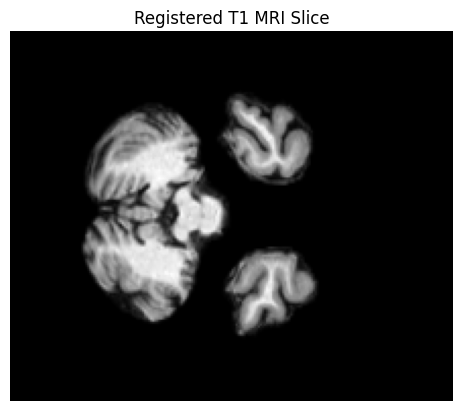

<class 'ants.core.ants_image.ANTsImage'>
Normalizing intensities
<class 'ants.core.ants_image.ANTsImage'>


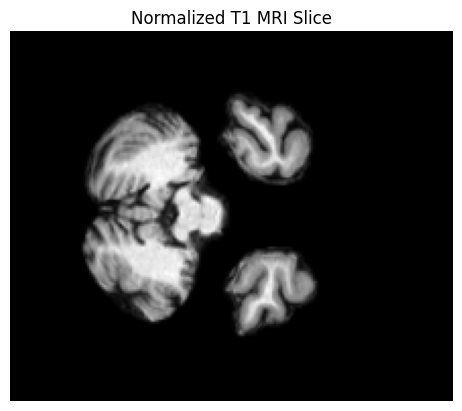

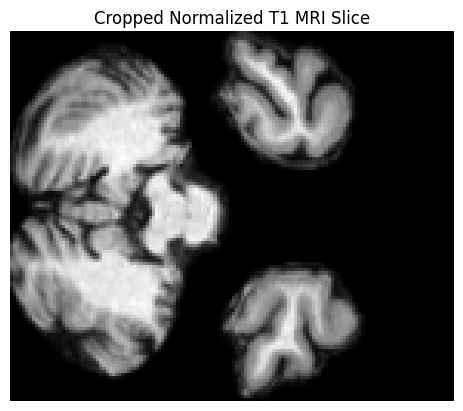

<class 'numpy.ndarray'>
<class 'ants.core.ants_image.ANTsImage'>


In [25]:
#dimensions 182×218×182 correspond to the default MNI152 1mm template from ANTs
#  standard ICBM 2009a MNI152 non-linear asymmetric template
# Paper may use slightly different MNI template, possibly an older version or a custom one (e.g., from FMRIPREP or SPM) with dimensions 193×229×193
# https://github.com/asharifisadr/MRI-Preprocessing/blob/main/Preprocessed_MRI.ipynb
import matplotlib.pyplot as plt
# Step 8: intensity normalized 
reg_path = './PREPROCESSED/ADNI_136_S_0426_MR_MPR____N3__Scaled_Br_20081013164839346_S51029_I120441_preprocessed.nii'
reg = ants.image_read(reg_path)

plt.imshow(reg[:, :, 31], cmap="gray")
plt.title("Registered T1 MRI Slice")
plt.axis("off")
plt.show()
print(type(reg))
print("Normalizing intensities")
t1_normalized_data = (reg.numpy() - np.min(reg.numpy())) / (
    np.max(reg.numpy()) - np.min(reg.numpy())
)

# Step 3: Convert back to ANTsImage
t1_normalized_data = ants.from_numpy(t1_normalized_data, origin=reg.origin, spacing=reg.spacing, direction=reg.direction)

print(type(t1_normalized_data))
plt.imshow(t1_normalized_data[:, :, 31], cmap="gray")
plt.title("Normalized T1 MRI Slice")
plt.axis("off")
plt.show()

# Step 9: center crop image to inner brain volume of 120 x 144 x 120 voxels (did same difference as paper but with new size) from 182 x 218 x 182 voxels 
crop_shape = (120, 144, 120) # per paper 
start = [(t1_normalized_data.shape[i] - crop_shape[i]) // 2 for i in range(3)] # get the start of halfway/center point for each dimension
end = [start[i] + crop_shape[i] for i in range(3)] # get the end of halfway/center point for each dimension
cropped_t1_data = t1_normalized_data[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

plt.imshow(cropped_t1_data[:, :, 0], cmap="gray")
plt.title("Cropped Normalized T1 MRI Slice")
plt.axis("off")
plt.show()
print(type(cropped_t1_data))
cropped_t1_data = ants.from_numpy(cropped_t1_data, origin=reg.origin, spacing=reg.spacing, direction=reg.direction)
print(type(cropped_t1_data))


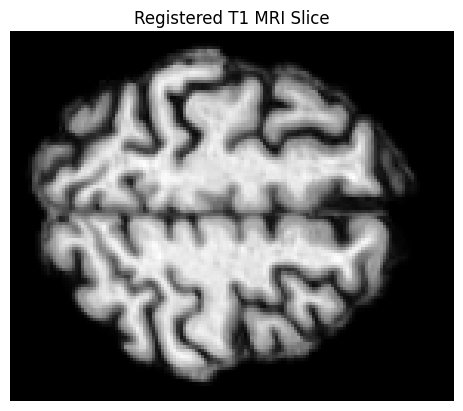

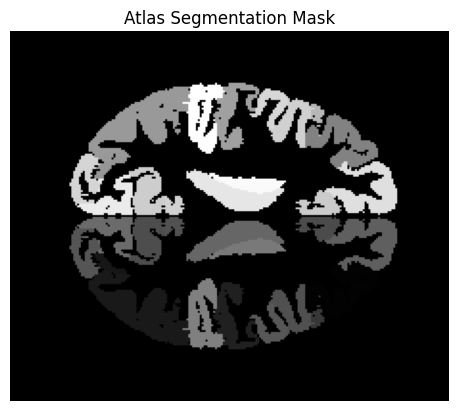

(193, 229, 193)
<class 'ants.core.ants_image.ANTsImage'>
<class 'ants.core.ants_image.ANTsImage'>
ANTsImage (RPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (120, 144, 120)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-90.0, 126.0, -72.0)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]



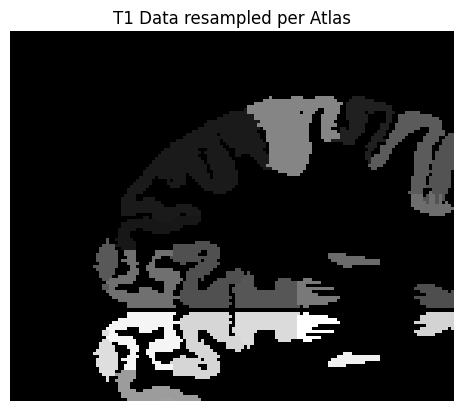

(120, 144, 120)


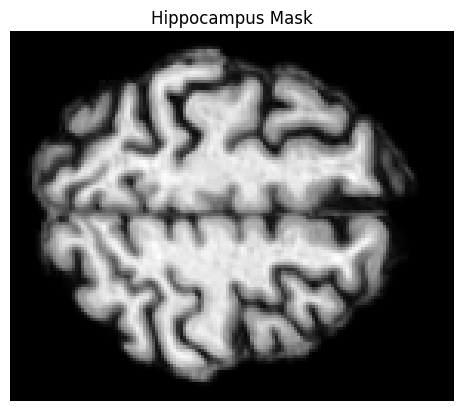

(120, 144, 120)
<class 'ants.core.ants_image.ANTsImage'>
(120, 144, 120)


In [46]:
# Segment the left and right hippocampus 
# install FSL for Linux: https://fsl.fmrib.ox.ac.uk/fsl/docs/#/install/linux
# or use Manera paper (https://www.nature.com/articles/s41597-020-0557-9) resource: https://gin.g-node.org/anamanera/CerebrA/src/master/
plt.imshow(cropped_t1_data[:, :, 100], cmap="gray")
plt.title("Registered T1 MRI Slice")
plt.axis("off")
plt.show()
# load in the cerebrA atlas 
atlas = ants.image_read("./CerebrA.nii")
plt.imshow(atlas[:, :, 100], cmap="gray")
plt.title("Atlas Segmentation Mask")
plt.axis("off")
plt.show()
print(atlas.shape)
print(type(atlas))
print(type(cropped_t1_data))
# resample the atlas to match the image's FOV and resolution 
atlas_resampled = ants.resample_image_to_target(atlas, cropped_t1_data, interp_type='nearestNeighbor')
print(atlas_resampled)
atlas_resampled_np = atlas_resampled.numpy()
plt.imshow(atlas_resampled[:, :, 100], cmap="gray")
plt.title("T1 Data resampled per Atlas")
plt.axis("off")
plt.show()
print(atlas_resampled.shape)

# segment the left and right hippocampus using the labels per https://gin.g-node.org/anamanera/CerebrA/src/master/CerebrA_LabelDetails.csv
hippocampus_labels = [53, 48] # [Mindboggle ID, CerebrA ID]
hippocampus_mask = np.isin(atlas_resampled_np, hippocampus_labels)

# dilate the hippocampus mask with a uniform 3 voxel dilation to ensure full coverage
from scipy.ndimage import binary_dilation
dilated_mask_np = binary_dilation(hippocampus_mask, iterations=3).astype(np.uint8)

# apply the mask 
cropped_t1_data[dilated_mask_np == True] = 53 # set the hippocampus segmentation to an arbitrary number not within the normalized range -- 53 per the atlas 
plt.imshow(cropped_t1_data[:, :, 100], cmap="gray")
plt.title("Hippocampus Mask")
plt.axis("off")
plt.show()
print(atlas_resampled.shape)
print(type(cropped_t1_data))
print(cropped_t1_data.shape)


In [39]:
if np.any(dilated_mask_np == 1):
    print("The mask contains elements that are equal to 1 (hippocampus present).")
else:
    print("The mask does not contain any elements that are equal to 1.")

The mask contains elements that are equal to 1 (hippocampus present).


In [52]:
from scipy.ndimage import binary_dilation
import os
def preprocess_image_part2(reg_path, image_dir, atlas):
    reg = ants.image_read(reg_path)
    # Intensity normalization
    t1_normalized_data = (reg.numpy() - np.min(reg.numpy())) / (
    np.max(reg.numpy()) - np.min(reg.numpy())
    )

    # Convert back to ANTsImage
    t1_normalized_data = ants.from_numpy(t1_normalized_data, origin=reg.origin, spacing=reg.spacing, direction=reg.direction)

    # Center crop image to inner brain volume of 120 x 144 x 120 voxels (did same difference as paper but with new size) from 182 x 218 x 182 voxels 
    crop_shape = (120, 144, 120) # per paper 
    start = [(t1_normalized_data.shape[i] - crop_shape[i]) // 2 for i in range(3)] # get the start of halfway/center point for each dimension
    end = [start[i] + crop_shape[i] for i in range(3)] # get the end of halfway/center point for each dimension
    cropped_t1_data = t1_normalized_data[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    # Convert back to ANTsImage
    cropped_t1_data = ants.from_numpy(cropped_t1_data, origin=reg.origin, spacing=reg.spacing, direction=reg.direction)

    ## resample the atlas to match the image's FOV and resolution 
    atlas_resampled = ants.resample_image_to_target(atlas, cropped_t1_data, interp_type='nearestNeighbor')
    atlas_resampled_np = atlas_resampled.numpy()

    # segment the left and right hippocampus using the labels per https://gin.g-node.org/anamanera/CerebrA/src/master/CerebrA_LabelDetails.csv
    hippocampus_labels = [53, 48] # [Mindboggle ID, CerebrA ID]
    hippocampus_mask = np.isin(atlas_resampled_np, hippocampus_labels)
    # dilate the hippocampus mask with a uniform 3 voxel dilation to ensure full coverage
    hippocampus_mask = binary_dilation(hippocampus_mask, iterations=3).astype(np.uint8)
    # apply the mask 
    cropped_t1_data[hippocampus_mask == True] = 53 # set the hippocampus segmentation to an arbitrary number not within the normalized range -- 53 per the atlas 


    # Save to directory
    filename = os.path.splitext(os.path.basename(reg_path))[0]
    output_dir = os.path.join(image_dir, filename + "_normCropSegment.nii")
    ants.image_write(cropped_t1_data, output_dir)
    
images_dir = './PREPROCESSED'
save_dir = './CROP_AND_SEGMENT'
i = 0
atlas = ants.image_read("./CerebrA.nii")
for dirpath, dirnames, filenames in os.walk(images_dir):
    for file in filenames:
        if file.endswith(".nii"):
            if i >= 350:
                t1_path = os.path.join(dirpath, file)
                print("iter ", i, ": Processing ", file)
                preprocess_image_part2(t1_path, save_dir, atlas)
                print("Done processing ", file)
            i += 1

iter  350 : Processing  ADNI_100_S_1286_MR_MPR-R____N3__Scaled_Br_20071103131952213_S38792_I80679_preprocessed.nii
Done processing  ADNI_100_S_1286_MR_MPR-R____N3__Scaled_Br_20071103131952213_S38792_I80679_preprocessed.nii


In [2]:
import persim

In [13]:
!export PATH=$PATH:/home/ggibson/dipha/build

In [1]:
# TDA Preprocessing
# using git clone https://github.com/DIPHA/dipha.git
import struct
import math
import matplotlib.image as mpimg
import ants
import matplotlib.pyplot as plt
from skimage.transform import resize

# Source: https://github.com/JamisonBlair/DIPHA-wrappers-for-Python/blob/main/save_image_data.py
# Allows to run DIPHA through Python 
def save_image_data(img, axis, superlevel=False):
    # Converts image into data for DIPHA to read.
    # Writes a binary file 'diphin' in current directory
    If the image is not grayscale, it converts to a nonunique grayscale version.
    
    c_image = ants.image_read(img).numpy()  # Convert ANTsPy image to NumPy array

    # Check if c_image is valid
    print("Image type:", type(c_image))
    print("Data type:", c_image.dtype)

    # Normalize preprocessed image safely
    #c_image = np.nan_to_num(c_image, nan=0.0, posinf=0.0, neginf=0.0)  # Remove invalid values
    c_image = (c_image - c_image.min()) / (c_image.max() - c_image.min())
    print("Voxel Intensity Range:", c_image.min(), c_image.max())
    # Apply contrast stretching to increase intensity variation
    c_image = (c_image - np.percentile(c_image, 5)) / (np.percentile(c_image, 95) - np.percentile(c_image, 5) + 1e-5)

    # Convert to binary mask based on threshold
    threshold_value = 0.001
    #c_image = (c_image >= threshold_value).astype('float32')

    plt.imshow(c_image[:,:,10])
    plt.colorbar()
    plt.show()

        
    #if superlevel is True, the following essentially inverts the image.
    if superlevel:
        c_image = math.ceil(c_image.max())-c_image
        
    #useful values    
    im_data =c_image.shape
    data_size = im_data[0]*im_data[1]*im_data[2]
    data_len = len(im_data)
    
    #Creates the file diphin and writes various ID 
    #information (as litte-endian int64 "<q") about
    #the image for DIPHA. First line is the DIPHA magic number.
    #Next, is the file typ identifier.
    fid = open('diphin', 'wb')
    fid.write(struct.pack('<q',8067171840))
    fid.write(struct.pack('<q',1))
    fid.write(struct.pack('<q',data_size))
    fid.write(struct.pack('<q',data_len))
    fid.write(struct.pack('<q',im_data[0]))
    fid.write(struct.pack('<q',im_data[1]))
    fid.write(struct.pack('<q',im_data[2]))
    
    #Writes the actual data in x-fastest order (MATLAB?).
    for i in np.nditer(c_image, order='C'):
        fid.write(struct.pack('d',i))
    
    #close file.
    fid.close()

def load_persistence_diagram(diphout):
    # persistence diagram. First column is the dimension, second column is the 
    # birth value, third column is the death value.
    #opens the file the output from DIPHA, diphout.
    file = open(diphout, "rb")
    
    #checks if diphout is actually a DIPHA file by checking the magic number.
    dipha_identifier = int.from_bytes(file.read(8), byteorder='little', signed=True)
    assert dipha_identifier == 8067171840, 'input is not a DIPHA file'
    
    #checks if diphout is in fact a persistence diagram.
    diagram_identifier = int.from_bytes(file.read(8), byteorder='little', signed=True)
    assert diagram_identifier == 2, 'input is not a persistence diagram'
    
    #number of generators
    num_pairs = int.from_bytes(file.read(8), byteorder='little', signed=True)
    
    #containers for the dimensions, births, and deaths.
    dims = []
    births = []
    deaths = []
    
    #Loops over num_pairs. Each iteration corresponds to 24 bits.
    #8 for the dimension, 8 for the birth value, 8 for the death value.
    #Appends the respective containers and decreases the value of num_pairs.
    while num_pairs > 0:
        dim = int.from_bytes(file.read(8), byteorder='little', signed=True)
        birth = struct.unpack('d', file.read(8))[0]
        death = struct.unpack('d', file.read(8))[0]
        
        dims.append(dim)
        births.append(birth)
        deaths.append(death)
        num_pairs = num_pairs - 1
    #once the file has been read, we close it.
    file.close()
    
    #returns a (num_pairs, 3) numpy array.
    #columns are dim, bith, death.
    #rows correspond to generators of the persistence diagram.
    return np.array([dims, births, deaths]).T

def im2PD(img, dual=False, superlevel=False, axis=0):
    # The DIPHA persistence diagram as a (n,3) numpy array based
    # on a grayscaled version of the image.
    # The n-1 rows are the (dim, birth, death) info for each generator of the 
    
    #save image data in binary file diphin for DIPHA to process.
    save_image_data(img, axis, superlevel=superlevel)
    
    #run DIPHA (or dual of DIPHA) on diphin file.
    #outputs file diphout in current directory.
    if dual:
	#replace dipha with [path to directory holding dipha]/dipha
        os.system('dipha --dual "diphin" "diphout"')
    else:
        print("running dipha")
	#replace dipha with [path to directory holding dipha]/dipha    
        os.system('/home/ggibson/dipha/build/dipha "diphin" "diphout"')
    
    #read DIPHA output diphout into human readable numpy array.
    per_diag = load_persistence_diagram("diphout")
    
    return per_diag


def generate_persistence_images(persistence_diagram, save_dir, reg_path):
    """
    Generates persistence images for dimensions d=0, d=1, d=2.

    Args:
    - persistence_diagram: A numpy array with shape (n,3) containing (dimension, birth, death).
    - save_dir: Directory where persistence images will be saved.
    - reg_path: File name used for saving images.

    Returns:
    - Saves persistence images per dimension in `save_dir`.
    """
    # Remove -1 placeholder entries
    print("Unique Birth-Death Pairs Before Thresholding:", np.unique(persistence_diagram[:, 1:], axis=0))


    # Define a quadratic weight function for persistence images
    def quadratic_weight(y, y_min=0, *args, **kwargs):
        return (y - y_min) ** 2

    # Initialize PersistenceImager with correct parameters
    persistence_imager = persim.PersistenceImager(
        weight=quadratic_weight,   # Quadratic weighting
        #pixel_size=5.0 / 50,       # Force 50x50 resolution
    )

    # Normalize persistence diagrams before transformation
    def normalize_persistence_diagram(persistence_diagram):
        """
        Normalizes persistence diagrams to a fixed birth-death range.
        """
        if persistence_diagram.shape[0] == 0:
            return persistence_diagram  # Return empty if no features exist

        # Compute min/max birth-death values
        birth_min, birth_max = np.min(persistence_diagram[:, 0]), np.max(persistence_diagram[:, 1])
        persistence_diagram = persistence_diagram.copy()  # Avoid modifying in-place
        persistence_diagram[:, 0] = (persistence_diagram[:, 0] - birth_min) / (birth_max - birth_min)
        persistence_diagram[:, 1] = (persistence_diagram[:, 1] - birth_min) / (birth_max - birth_min)
        
        return persistence_diagram

    # Extract and normalize persistence diagrams per dimension
    dimensional_diagrams = {
        dim: (persistence_diagram[persistence_diagram[:, 0] == dim, 1:3])
        for dim in [0, 1, 2]
    }

    filename = os.path.splitext(os.path.basename(reg_path))[0]

    for dim, diag in dimensional_diagrams.items():
        if diag.shape[0] > 0:
            # Generate persistence image
            persistence_image = persistence_imager.fit_transform(diag)
            persistence_image = resize(persistence_image, (50, 50), anti_aliasing=True)
            # Save image as `.npy`
            output_path = os.path.join(save_dir, f"{filename}_tda_{dim}.npy")
            np.save(output_path, persistence_image)
            print(f"Saved Persistence Image for d={dim}: {output_path}")

            # Visualize persistence image
            plt.imshow(persistence_image, cmap="hot", interpolation="nearest")
            plt.colorbar()
            plt.title(f"Persistence Image (d={dim})")
            #plt.savefig(os.path.join(save_dir, f"{filename}_tda_{dim}.png"))
            plt.show()
        else:
            print(f"No features found for dimension {dim}, skipping.")
    # persistence_diagram = persistence_diagram[:, 1:3]
    # if np.any(np.isnan(persistence_diagram)) or np.any(np.isinf(persistence_diagram)):
    #     print("Persistence diagram 0 contains NaN or infinite values.")
    #     # Remove NaN or infinite values (e.g., replace them with a large number or remove rows)
    #     persistence_diagram = persistence_diagram[~np.isnan(persistence_diagram).any(axis=1)]
    #     persistence_diagram = persistence_diagram[~np.isinf(persistence_diagram).any(axis=1)]
    # # if np.any(np.isnan(persistence_diagram_1)) or np.any(np.isinf(persistence_diagram_1)):
    # #     print("Persistence diagram 1 contains NaN or infinite values.")
    # #     # Remove NaN or infinite values (e.g., replace them with a large number or remove rows)
    # #     persistence_diagram_1 = persistence_diagram_1[~np.isnan(persistence_diagram_1).any(axis=1)]
    # #     persistence_diagram_1 = persistence_diagram_1[~np.isinf(persistence_diagram_1).any(axis=1)]
    # # if np.any(np.isnan(persistence_diagram_2)) or np.any(np.isinf(persistence_diagram_2)):
    # #     print("Persistence diagram 2 contains NaN or infinite values.")
    # #     # Remove NaN or infinite values (e.g., replace them with a large number or remove rows)
    # #     persistence_diagram_2 = persistence_diagram_2[~np.isnan(persistence_diagram_2).any(axis=1)]
    # #     persistence_diagram_2 = persistence_diagram_2[~np.isinf(persistence_diagram_2).any(axis=1)]

    # # Ensure that the persistence diagrams are non-empty
    # if persistence_diagram.shape[0] == 0:
    #     print("No features found for dimension ", dim)

    # filename = os.path.splitext(os.path.basename(reg_path))[0]
    # # calculate persistence image for each dimension [0,1,2]
    # if persistence_diagram.shape[0] != 0:
    #     persistence_image = persistence_imager.fit_transform(persistence_diagram)
    #     output_dir = os.path.join(save_dir, filename + "_tda_" + str(dim) + ".nii")

    #     plt.imshow(persistence_image, cmap="hot")
    #     plt.colorbar()
    #     plt.savefig("persistence_image.png")
    #     plt.show()
    #     np.save(output_dir, persistence_image)
    # # if persistence_diagram_1.shape[0] != 0:
    # #     persistence_image_1 = persistence_imager.fit_transform(persistence_diagram_1)
    # #     output_dir = os.path.join(save_dir, filename + "_tda_1.nii")
    # #     np.save(output_dir, persistence_image_1)
    # # if persistence_diagram_1.shape[0] != 0:
    # #     persistence_image_2 = persistence_imager.fit_transform(persistence_diagram_2)
    # #     output_dir = os.path.join(save_dir, filename + "_tda_2.nii")
    # #     np.save(output_dir, persistence_image_2)




# takes an image, runs through DIPHA, and calculates the persistence homology calulcation on each image

# Apply the threshold to create a binary mask (superlevel set)


images_dir = './PREPROCESSED'
save_dir = './TDA_V2'
i = 0

import os

numDims = 3 

for dirpath, dirnames, filenames in os.walk(images_dir):
    for file in filenames:
        print(file)
        if file.endswith(".nii"):
            if i >= 0:
                t1_path = os.path.join(dirpath, file)
                print("iter ", i, ": Processing ", file)
                #for dim in range(numDims): # calculate persistence diagram and image for each dimension [0,1,2]
                #    print("Dimension: ", dim, " for ", file)
                persistence_diagram  = im2PD(t1_path, False, False, 0) # includes thresholding 
                print("Persistence Diagram:", persistence_diagram)
                generate_persistence_images(persistence_diagram, save_dir, t1_path)
                
                #break


                print("Done processing ", file)
            i += 1

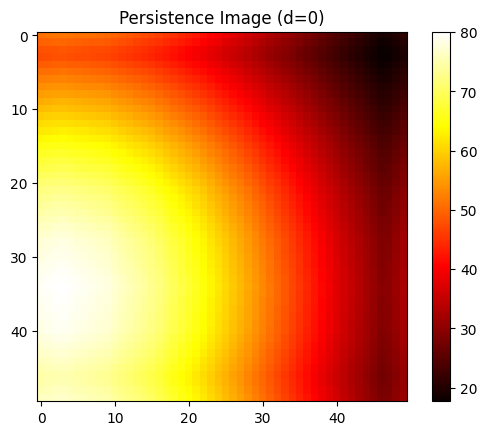

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
persistence_image = np.load('./TDA_V2/ADNI_002_S_0413_MR_MPR____N3__Scaled_Br_20070216232854688_S14782_I40657_preprocessed_tda_2.npy')
plt.imshow(persistence_image, cmap="hot", interpolation="nearest")
plt.colorbar()
plt.title(f"Persistence Image (d={0})")
#plt.savefig(os.path.join(save_dir, f"{filename}_tda_{dim}.png"))
plt.show()

fmriprep4 was used to perform registration to MNI reference space,
bias field correction, and brain extraction for all images. The obtained 193×229×193 pixel
images were intensity normalised

However, fmriprep expects a bids input which is not possible at the moment with the MPRAGEMETA.csv missing from the ADNI database. Need to breakdown these steps within the fmriprep4 pipeline to manually apply each process/step

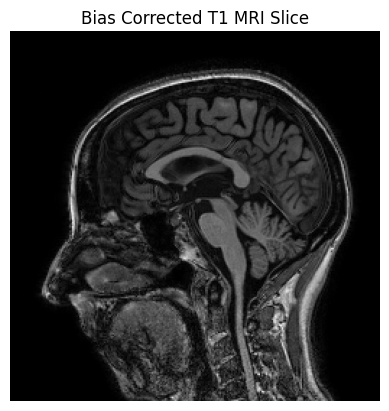

In [49]:
# source: https://github.com/asharifisadr/MRI-Preprocessing/blob/main/Preprocessed_MRI.ipynb
# apply N4 bias field correction on test path

#t1_ants = ants.image_read(t1_path_test)
t1_corrected = ants.n4_bias_field_correction(t1_ants)

plt.imshow(t1_corrected.numpy()[:, :, t1_corrected.shape[2] // 2], cmap="gray")
plt.title("Bias Corrected T1 MRI Slice")
plt.axis("off")
plt.show()

Image type: <class 'numpy.ndarray'>
Data type: float32
Voxel Intensity Range: 0.0 1.0


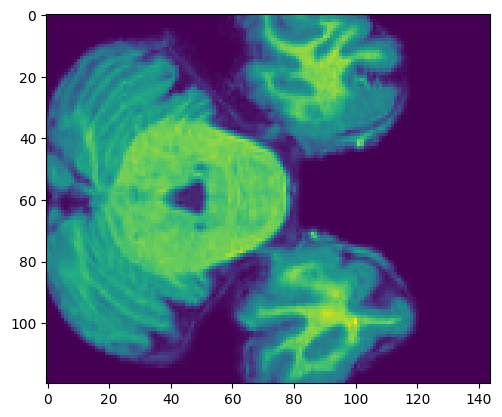

In [ ]:
img = './CROP_AND_SEGMENT/ADNI_002_S_0413_MR_MPR____N3__Scaled_2_Br_20081001114937668_S14782_I118675_preprocessed_normCropSegment.nii'
c_image = ants.image_read(img).numpy()  # Convert ANTsPy image to NumPy array

# Check if c_image is valid
print("Image type:", type(c_image))
print("Data type:", c_image.dtype)

# Normalize preprocessed image safely
#c_image = np.nan_to_num(c_image, nan=0.0, posinf=0.0, neginf=0.0)  # Remove invalid values
c_image = (c_image - c_image.min()) / (c_image.max() - c_image.min())
print("Voxel Intensity Range:", c_image.min(), c_image.max())
# Apply contrast stretching to increase intensity variation
c_image = (c_image - np.percentile(c_image, 5)) / (np.percentile(c_image, 95) - np.percentile(c_image, 5) + 1e-5)

# Convert to binary mask based on threshold
threshold_value = 0.001
#c_image = (c_image >= threshold_value).astype('float32')

plt.imshow(c_image[:,:,10],)

In [50]:
t1_corrected.shape

(256, 256, 170)

In [52]:
# Brain extraction using skull stripping from ants

if isinstance(t1_corrected, ants.ANTsImage):
    try:
        t1_brain = antspynet.brain_extraction(t1_corrected, modality="t1", verbose=True)
    except Exception as e:
        print("Brain extraction failed:", str(e))
else:
    raise ValueError("The image is not a valid ANTsImage")

Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction failed: object __array__ method not producing an array


In [ ]:
plt.imshow(t1_skull_stripped.numpy()[:, :, t1_skull_stripped.shape[2] // 2], cmap="gray")
plt.title("Skull Stripped T1 MRI Slice")
plt.axis("off")
plt.show()

In [ ]:
# registration to MNI reference spaceusing ants 
template = ants.image_read(ants.get_ants_data("mni"))
reg = ants.registration(fixed=template, moving=t1_skull_stripped, type_of_transform="Affine")
plt.imshow(reg['warpedmovout'].numpy()[:, :, reg['warpedmovout'].shape[2] // 2], cmap="gray")
plt.title("Registered T1 MRI Slice")
plt.axis("off")
plt.show()

In [ ]:
# perform this pipeline (bias field correction, brain extraction, registration to MNI space, and intensity normalization)
# on each image within the downloaded ADNI dataset 


# include cropping to inner brain volume of 120 x 144 x 120 voxels to exclude anatomy outside of the brain